# EDA: Шаблон анализа группы признаков

Хакатон ChemAI: Predict the Cure.
В этом ноутбуке выполняется разведочный анализ данных для одной из групп молекулярных дескрипторов.

Объединяет чек-лист команды Jazz и лучшие практики из примера по анализу корреляций.

Перед началом работы скопируйте ноутбук под именем `eda_group<номер>_<имя>.ipynb` и замените список `FEATURES` на свои признаки.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import VarianceThreshold
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

SEED = 42
np.random.seed(SEED)


## Загрузка данных

Файлы `train.csv`, `test.csv` должны находиться в папке `data/`.


In [2]:
!gdown --folder https://drive.google.com/drive/folders/1m1PS44rF9HqIAOUZQeopU5sqwgi6YfO8 -O data

Retrieving folder contents
Processing file 1LL6moSzpUVxJUTMeXihWvUxBJNjvj6EH sample_submission.csv
Processing file 1Ui2t87X3in-Wu-pnjkDXa_VtPsVafi0l test.csv
Processing file 159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl train.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1LL6moSzpUVxJUTMeXihWvUxBJNjvj6EH
To: /content/data/sample_submission.csv
100% 15.4k/15.4k [00:00<00:00, 50.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ui2t87X3in-Wu-pnjkDXa_VtPsVafi0l
To: /content/data/test.csv
100% 441k/441k [00:00<00:00, 119MB/s]
Downloading...
From: https://drive.google.com/uc?id=159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl
To: /content/data/train.csv
100% 1.36M/1.36M [00:00<00:00, 109MB/s]
Download completed


In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

# Переименовываем таргеты для удобства (в исходном train они с единицами измерения)
train.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'}, inplace=True)
train.set_index('index', inplace=True)

train.head()

,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
index,,,,,,,,,,,,,,,,,,,,,
0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,...,1,0,0,0,0,0,0,0,0,0
1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,...,0,1,0,0,0,0,0,0,0,0
2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,315.457,...,0,0,0,0,0,0,0,0,0,0
3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,439.375,...,0,0,1,0,0,0,0,0,0,0
4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,...,0,0,0,0,0,0,0,0,0,0


## Первичный обзор

Общая информация о данных и статистики.


In [4]:
train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 751 entries, 0 to 750
Data columns (total 213 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    IC50                      float64
 1    CC50                      float64
 2    SI                        float64
 3    MaxAbsEStateIndex         float64
 4    MaxEStateIndex            float64
 5    MinAbsEStateIndex         float64
 6    MinEStateIndex            float64
 7    qed                       float64
 8    SPS                       float64
 9    MolWt                     float64
 10   HeavyAtomMolWt            float64
 11   ExactMolWt                float64
 12   NumValenceElectrons       int64  
 13   NumRadicalElectrons       int64  
 14   MaxPartialCharge          float64
 15   MinPartialCharge          float64
 16   MaxAbsPartialCharge       float64
 17   MinAbsPartialCharge       float64
 18   FpDensityMorgan1          float64
 19   FpDensityMorgan2          float64
 20   FpDensityMorg

In [5]:
train.describe().round(3)

,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000,751.000,751.000,751.000,751.000,751.000,751.000,751.000,751.000,751.000,...,751.000,751.000,751.000,751.000,751.000,751.000,751.0,751.000,751.000,751.000
mean,204.544,577.426,89.153,10.860,10.860,0.180,-0.972,0.578,29.588,352.407,...,0.056,0.013,0.011,0.001,0.001,0.055,0.0,0.069,0.182,0.007
std,370.368,641.515,788.882,3.347,3.347,0.169,1.594,0.214,12.713,129.071,...,0.272,0.115,0.103,0.036,0.036,0.227,0.0,0.254,1.227,0.081
min,0.004,0.701,0.011,2.322,2.322,0.000,-6.993,0.060,9.545,110.156,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000
25%,13.222,99.999,1.500,8.921,8.921,0.048,-1.334,0.443,18.306,266.252,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000
50%,44.069,376.581,4.000,12.198,12.198,0.121,-0.419,0.636,29.281,319.129,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000
75%,206.787,877.509,17.372,13.214,13.214,0.291,0.072,0.742,38.875,410.537,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000
max,4095.189,4538.976,15620.600,15.933,15.933,1.375,1.375,0.947,60.273,904.777,...,2.000,1.000,1.000,1.000,1.000,1.000,0.0,1.000,20.000,1.000


## Анализ целевых переменных

Распределения `IC50`, `CC50`, `SI` и их логарифмов (log1p).


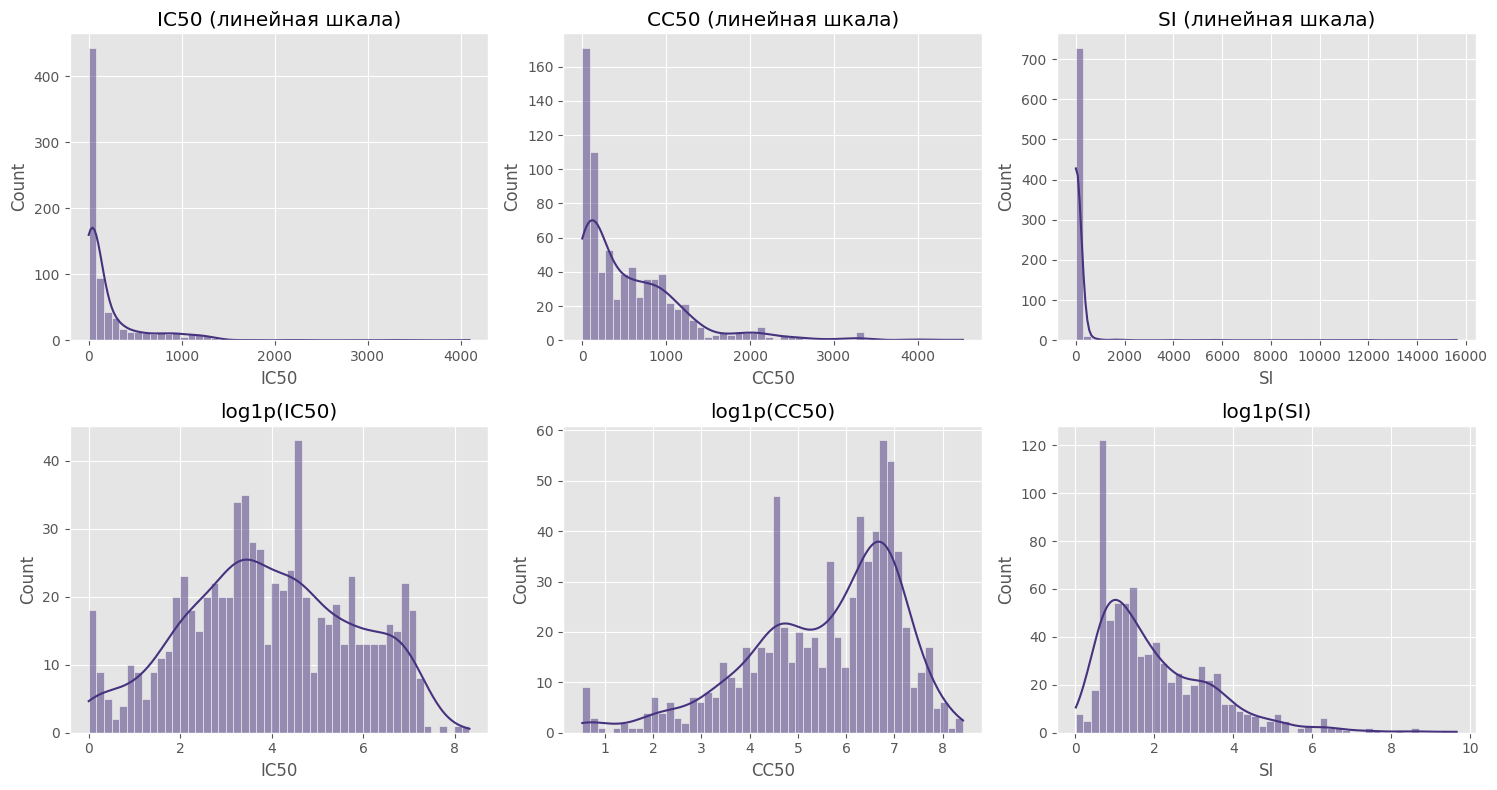

In [6]:
targets = ['IC50', 'CC50', 'SI']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(targets):
    sns.histplot(train[col], bins=50, ax=axes[0, i], kde=True)
    axes[0, i].set_title(f'{col} (линейная шкала)')
    sns.histplot(np.log1p(train[col]), bins=50, ax=axes[1, i], kde=True)
    axes[1, i].set_title(f'log1p({col})')
plt.tight_layout()
plt.show()


Вывод: все три таргета имеют левостороннюю асимметрию. Для моделирования рекомендуется применять логарифмирование (log1p).


## Признаки группы

In [7]:
train.columns[train.columns.str.contains('^fr_')]

Index(['fr_Al_COO', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN', 'fr_Ar_COO',
       'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_COO', 'fr_COO2', 'fr_C_O',
       'fr_C_O_noCOO', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH0', 'fr_NH1',
       'fr_NH2', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Ndealkylation2',
       'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_carbamate',
       'fr_alkyl_halide', 'fr_allylic_oxid', 'fr_amide', 'fr_amidine',
       'fr_aniline', 'fr_aryl_methyl', 'fr_azide', 'fr_azo', 'fr_barbitur',
       'fr_benzene', 'fr_benzodiazepine', 'fr_bicyclic', 'fr_diazo',
       'fr_dihydropyridine', 'fr_epoxide', 'fr_ester', 'fr_ether', 'fr_furan',
       'fr_guanido', 'fr_halogen', 'fr_hdrzine', 'fr_hdrzone', 'fr_imidazole',
       'fr_imide', 'fr_isocyan', 'fr_isothiocyan', 'fr_ketone',
       'fr_ketone_Topliss', 'fr_lactam', 'fr_lactone', 'fr_methoxy',
       'fr_morpholine', 'fr_nitrile', 'fr_nitro', 'fr_nitro_arom',
       'fr_nitro_arom_nonortho', 'fr_nitroso', 'fr_oxazole', 'fr

**Алифатические и ароматические кислородсодержащие группы**

`fr_Al_COO` — алифатическая карбоновая кислота (R-COOH)\
`fr_Al_OH` — алифатический гидроксил (спирт)\
`fr_Al_OH_noTert` — алифатический гидроксил, кроме третичных спиртов\
`fr_Ar_COO` — ароматическая карбоновая кислота (например, бензойная кислота)\
`fr_Ar_OH` — фенольный гидроксил на ароматическом кольце\
`fr_COO` — любая карбоксильная группа\
`fr_COO2` — карбоксилат/эфир карбоновой кислоты\
`fr_C_O` — карбонильная группа (C=O)\
`fr_C_O_noCOO` — карбонил, исключая карбоновые кислоты и эфиры\
`fr_ester` — сложный эфир\
`fr_ether` — простой эфир (R-O-R)\
`fr_ketone` — кетон\
`fr_ketone_Topliss` — кетон по классификации Topliss\
`fr_aldehyde` — альдегид\
`fr_lactone` — циклический эфир (лактон)\
`fr_methoxy` — метокси-группа (-OCH3)\
`fr_oxime` — оксим (C=N-OH)\
`fr_phenol` — фенол\
`fr_phenol_noOrthoHbond` — фенол без возможности внутримолекулярной ortho-H связи

**Азотсодержащие группы**

`fr_ArN` — ароматический атом азота\
`fr_Ar_N` — ароматический амин, связанный с ароматической системой\
`fr_Ar_NH` — ароматический NH\
`fr_NH0` — третичный амин (без H при N)\
`fr_NH1` — вторичный амин\
`fr_NH2` — первичный амин\
`fr_N_O` — N–O связь\
`fr_Ndealkylation1` — фрагмент, подверженный N-деалкилированию типа 1\
`fr_Ndealkylation2` — фрагмент, подверженный N-деалкилированию типа 2\
`fr_Nhpyrrole` — пиррольный NH\
`fr_amide` — амид\
`fr_amidine` — амидин\
`fr_aniline` — анилиноподобная группа\
`fr_azide` — азид (-N3)\
`fr_azo` — азо-группа (-N=N-)\
`fr_diazo` — диазо-группа\
`fr_guanido` — гуанидиновая группа\
`fr_hdrzine` — гидразин\
`fr_hdrzone` — гидразон\
`fr_imide` — имид\
`fr_Imine` — имин (C=N)\
`fr_isocyan` — изоцианат (-N=C=O)\
`fr_nitrile` — нитрил (-C≡N)\
`fr_nitro` — нитрогруппа (-NO2)\
`fr_nitro_arom` — ароматическая нитрогруппа\
`fr_nitro_arom_nonortho` — ароматическая нитрогруппа без ortho-замещения\
`fr_nitroso` — нитрозогруппа (-N=O)\
`fr_priamide` — первичный амид\
`fr_quatN` — четвертичный аммоний\
`fr_sulfonamd` — сульфонамид\
`fr_prisulfonamd` — первичный сульфонамид\
`fr_urea` — мочевина/уреидная группа\
`fr_tetrazole` — тетразол\
`fr_barbitur` — барбитуратный фрагмент\
`fr_benzodiazepine` — бензодиазепиновый фрагмент\
`fr_dihydropyridine` — дигидропиридин\
`fr_imidazole` — имидазол\
`fr_lactam` — циклический амид (лактам)\
`fr_morpholine` — морфолиновое кольцо\
`fr_oxazole` — оксазол\
`fr_piperdine` — пиперидин\
`fr_piperzine` — пиперазин\
`fr_pyridine` — пиридин

**Серосодержащие группы**

`fr_C_S` — тиокарбонильная группа (C=S)\
`fr_SH` — тиол (-SH)\
`fr_isothiocyan` — изотиоцианат (-N=C=S)\
`fr_sulfide` — сульфид (R-S-R)\
`fr_sulfone` — сульфон (SO2)\
`fr_thiocyan` — тиоцианат (-SCN)\
`fr_thiophene` — тиофен\
`fr_thiazole` — тиазол

**Фосфорсодержащие группы**

`fr_phos_acid` — фосфоновая/фосфорная кислота\
`fr_phos_ester` — эфир фосфорной кислоты

**Галогены и галогенсодержащие группы**

`fr_alkyl_halide` — алкилгалогенид\
`fr_halogen` — любой галоген (F, Cl, Br, I)

**Гетероциклы и ароматические системы**

`fr_benzene` — бензольное кольцо\
`fr_bicyclic` — бициклическая система\
`fr_furan` — фуран\
`fr_thiophene` — тиофен\
`fr_imidazole` — имидазол\
`fr_oxazole` — оксазол\
`fr_thiazole` — тиазол\
`fr_pyridine` — пиридин

**Реакционноспособные и специальные группы**

`fr_allylic_oxid` — аллильный центр, склонный к окислению\
`fr_epoxide` — эпоксид\
`fr_para_hydroxylation` — позиция, склонная к para-гидроксилированию\
`fr_term_acetylene` — терминальный ацетилен (-C≡CH)\
`fr_unbrch_alkane` — неразветвлённый алкан\
`fr_aryl_methyl` — арил-метильный фрагмент (Ar-CH3)

In [8]:
GROUP_NAME = r'Функциональные группы (fr_*)'
FEATURES = train.columns[train.columns.str.contains('^fr_')].to_list()
TARGETS = ['IC50', 'CC50', 'SI']

In [9]:
targets = train[TARGETS]
train = train[FEATURES]

## Анализ пропусков

Проверка наличия пропущенных значений в выбранной группе признаков.


In [10]:
missing_percent = (train[FEATURES].isnull().sum() / len(train)) * 100
missing_df = pd.DataFrame({
    'column': missing_percent.index,
    'missing_%': missing_percent.values,
    'missing_abs': train[FEATURES].isnull().sum().values
})
missing_df = missing_df.sort_values('missing_%', ascending=False)
missing_df = missing_df[missing_df['missing_%'] > 0]

if len(missing_df) == 0:
    print('Пропуски в группе отсутствуют.')
else:
    print('Пропущенные значения в группе:')
    print(missing_df)


Пропуски в группе отсутствуют.


## Анализ распределений

Гистограммы и boxplot для каждого признака группы.


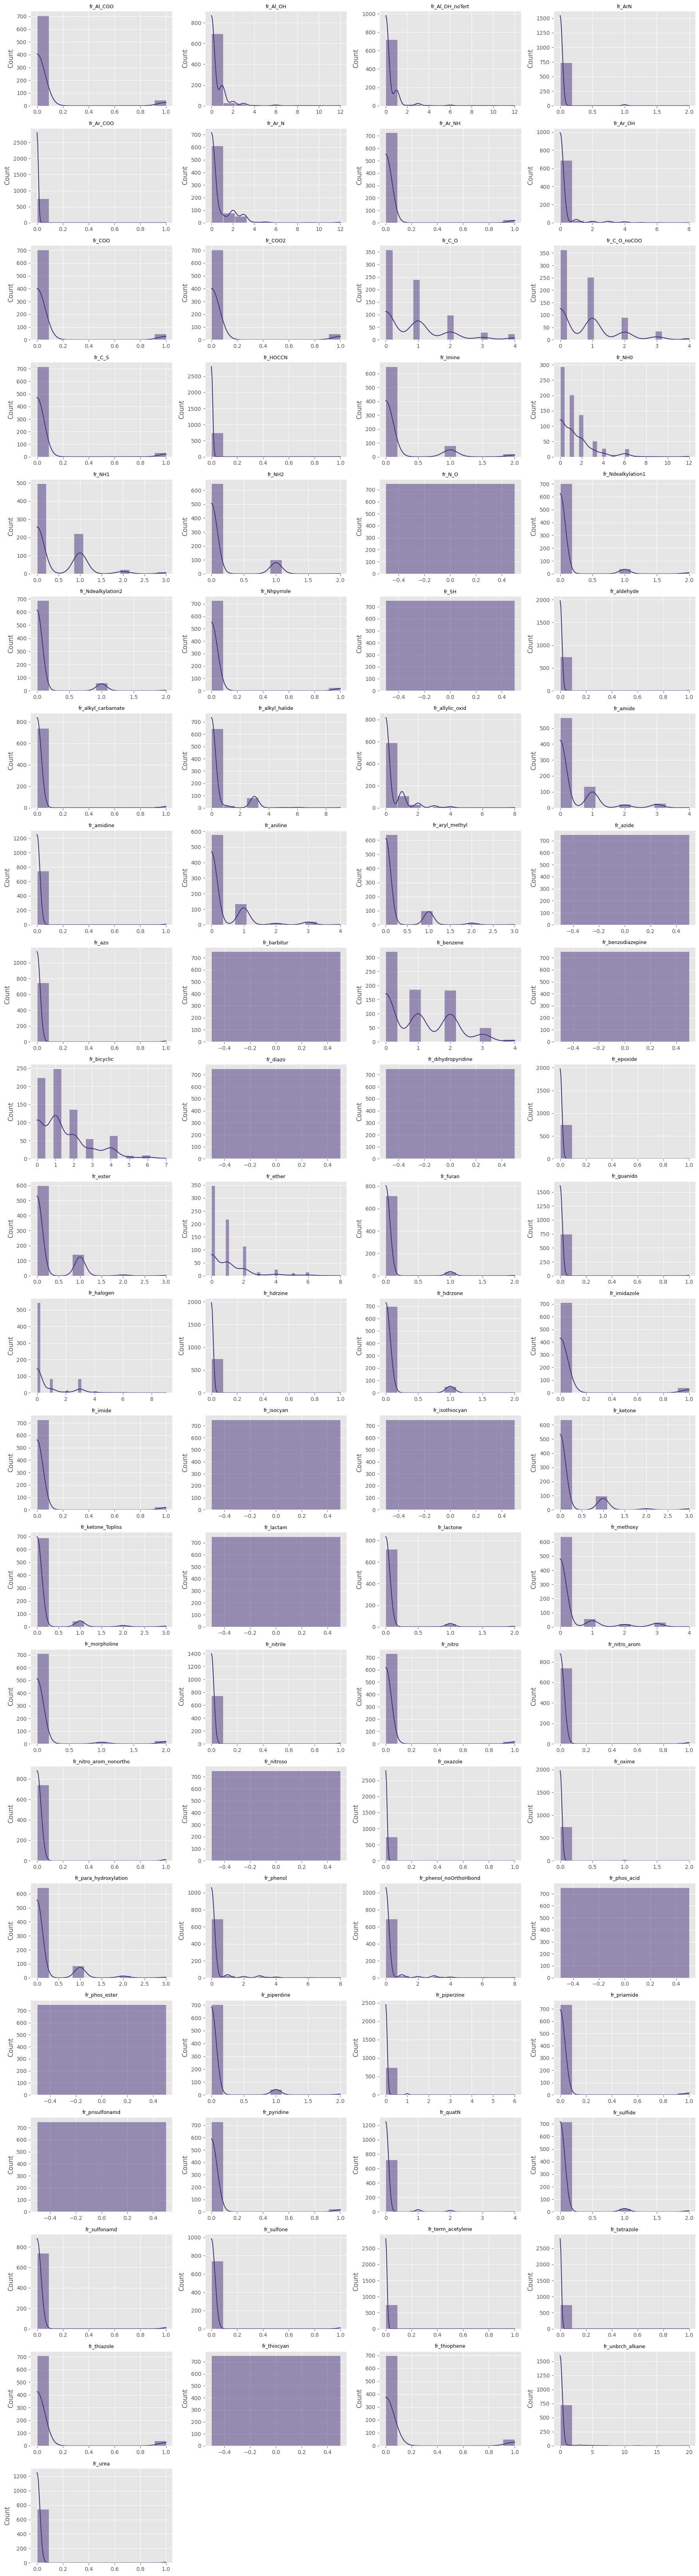

In [11]:
n_cols = 4
n_rows = int(np.ceil(len(train.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()
for i, feat in enumerate(train.columns):
    ax = axes[i]
    sns.histplot(train[feat], kde=True, ax=ax)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


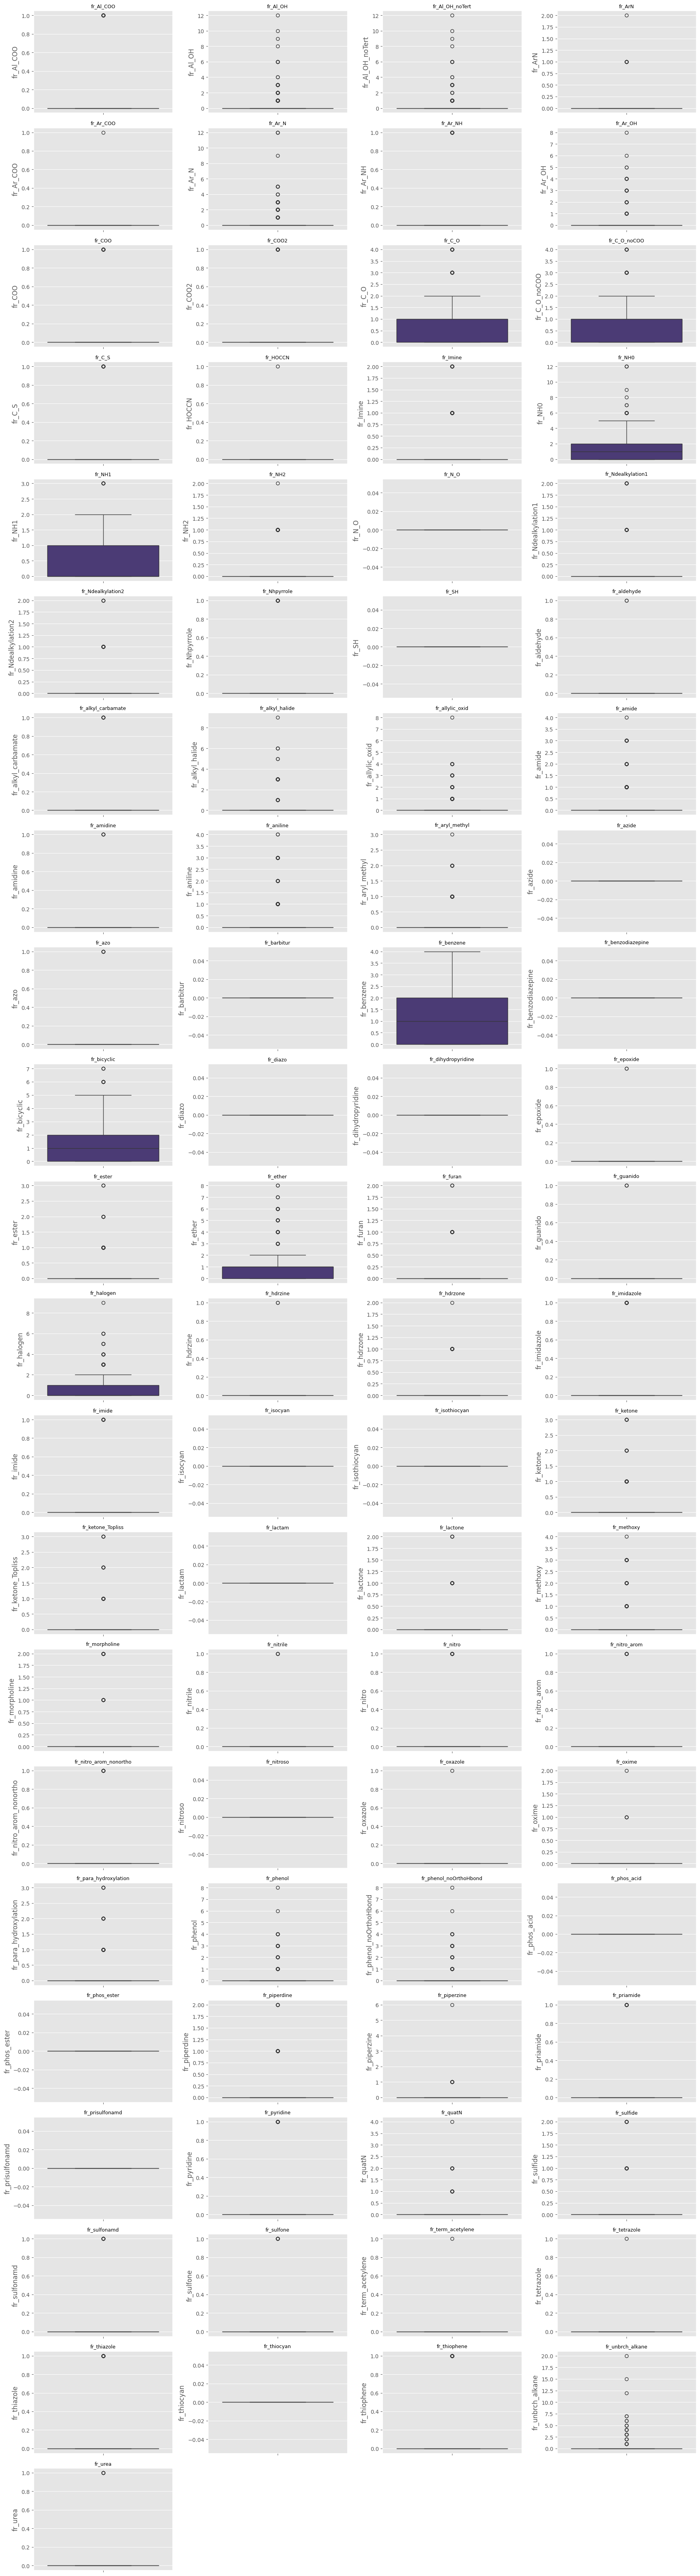

In [12]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()
for i, feat in enumerate(train.columns):
    ax = axes[i]
    sns.boxplot(y=train[feat], ax=ax)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


## Корреляционный анализ

Сразу уберём те признаки, дисперсия которых меньше установленного порога (в шаблоне было взято 0.01).

In [13]:
selector = VarianceThreshold(0.01)
train = pd.DataFrame(selector.fit_transform(train), columns=selector.get_feature_names_out())
print(f'Осталось {train.shape[1]} из {len(FEATURES)} признаков')

Осталось 57 из 85 признаков


Теперь посчитаем корреляционную матрицу. Использовать будем корреляцию Спирмена, поскольку данные представляют собой номинальные признаки и в большинстве признаков наблюдается большой перекос влево в распределении.

In [14]:
corr = train.corr(method='spearman').abs()
corr

,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,...,fr_piperzine,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_thiazole,fr_thiophene,fr_unbrch_alkane
fr_Al_COO,1.000000,0.063135,0.030475,0.029329,0.143129,0.046850,0.074985,0.988370,0.988370,0.376586,...,0.030781,0.037249,0.043858,0.050588,0.078498,0.029329,0.026197,0.060669,0.107940,0.052371
fr_Al_OH,0.063135,1.000000,0.850436,0.015715,0.073005,0.088552,0.283980,0.065615,0.065615,0.177706,...,0.068619,0.247304,0.047065,0.112776,0.122536,0.058951,0.030637,0.085064,0.019939,0.013973
fr_Al_OH_noTert,0.030475,0.850436,1.000000,0.002797,0.005714,0.068959,0.364055,0.032777,0.032777,0.142641,...,0.057388,0.280644,0.023088,0.094317,0.102480,0.089206,0.016711,0.055035,0.063416,0.020349
fr_ArN,0.029329,0.015715,0.002797,1.000000,0.071281,0.021557,0.050566,0.029674,0.029674,0.047328,...,0.014163,0.017140,0.049534,0.023277,0.090153,0.013495,0.012054,0.074215,0.014014,0.024098
fr_Ar_N,0.143129,0.073005,0.005714,0.071281,1.000000,0.310879,0.010662,0.130241,0.130241,0.020414,...,0.069120,0.251526,0.272279,0.113598,0.037687,0.065859,0.027990,0.367473,0.003581,0.071697
fr_Ar_NH,0.046850,0.088552,0.068959,0.021557,0.310879,1.000000,0.029238,0.047401,0.047401,0.170273,...,0.022624,0.027379,0.187851,0.037183,0.065546,0.021557,0.197657,0.044593,0.050613,0.038494
fr_Ar_OH,0.074985,0.283980,0.364055,0.050566,0.010662,0.029238,1.000000,0.056508,0.056508,0.066648,...,0.036211,0.011674,0.032411,0.009658,0.064664,0.034503,0.030819,0.006906,0.081009,0.015064
fr_COO,0.988370,0.065615,0.032777,0.029674,0.130241,0.047401,0.056508,1.000000,1.000000,0.375600,...,0.031143,0.037688,0.044374,0.051184,0.076486,0.029674,0.026505,0.061383,0.105321,0.052988
fr_COO2,0.988370,0.065615,0.032777,0.029674,0.130241,0.047401,0.056508,1.000000,1.000000,0.375600,...,0.031143,0.037688,0.044374,0.051184,0.076486,0.029674,0.026505,0.061383,0.105321,0.052988
fr_C_O,0.376586,0.177706,0.142641,0.047328,0.020414,0.170273,0.066648,0.375600,0.375600,1.000000,...,0.050509,0.088122,0.001614,0.108888,0.074927,0.061488,0.002005,0.113774,0.113195,0.135460


Теперь используем иерархическую кластеризацию, чтобы определить группы коррелированных признаков.

In [15]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

distance_matrix = 1 - corr

dist_array = squareform(distance_matrix)
Z = linkage(dist_array, method='average')

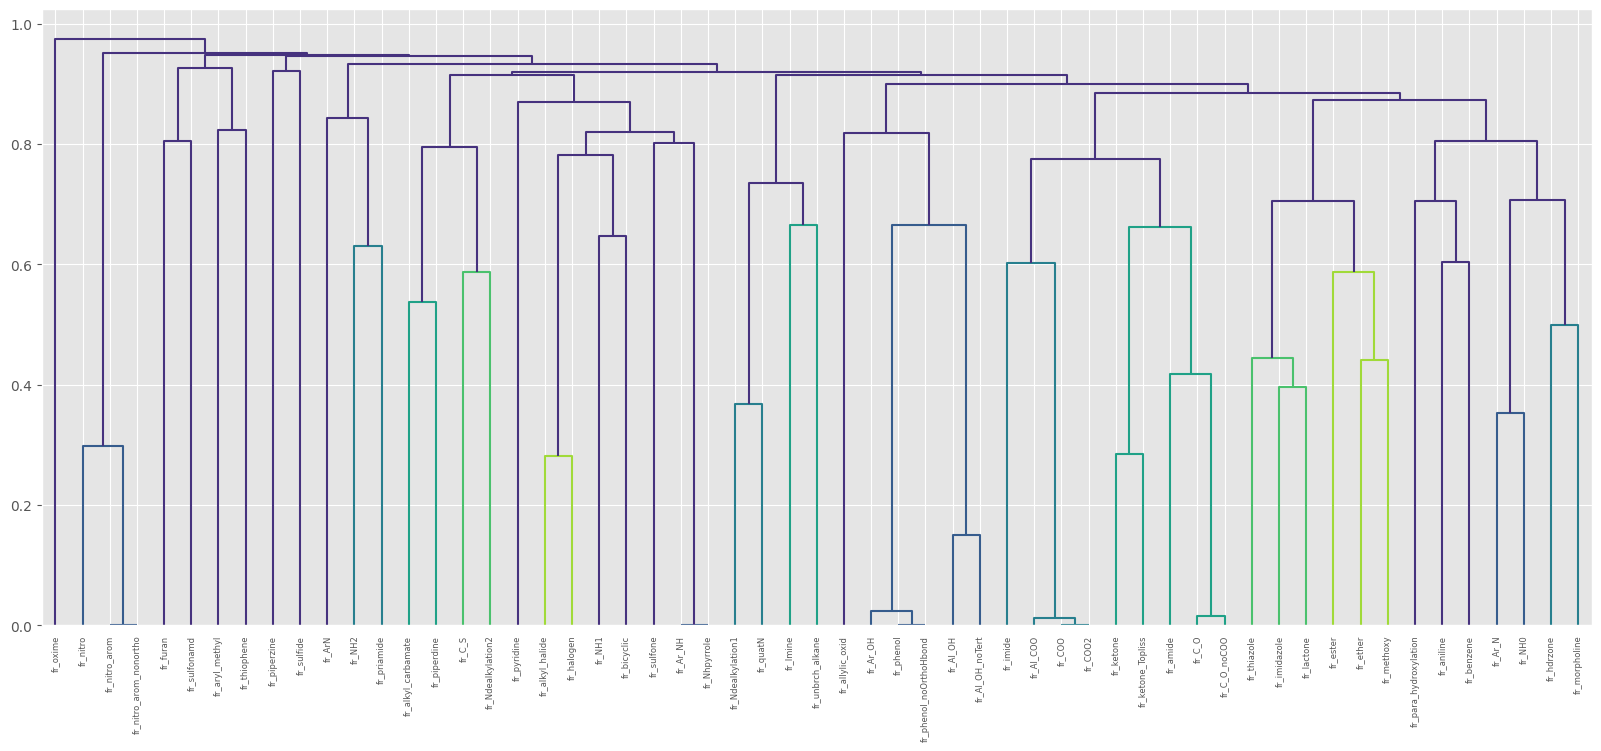

In [16]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(20, 8))

dendrogram(
    Z,
    labels=train.columns,
    leaf_rotation=90
);

В кластеризации будем использовать $t=0.2$ (т.е. собирать в кластер будем при коэффициенте корреляции $r \ge 0.8$). Можно было бы взять $t > 0.2$ (следовательно, собирать в кластер признаки с $r < 0.8$), но тогда есть риск потерять значимые для таргетов дескрипторы. Для безопасного EDA лучше не рисковать.

In [17]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(
    Z,
    t=0.2,
    criterion='distance'
)

cluster_dict = {}

for feature, cluster_id in zip(train.columns, clusters):
    cluster_dict.setdefault(cluster_id, []).append(feature)

cluster_dict

{np.int32(30): ['fr_Al_COO', 'fr_COO', 'fr_COO2'],
 np.int32(28): ['fr_Al_OH', 'fr_Al_OH_noTert'],
 np.int32(11): ['fr_ArN'],
 np.int32(45): ['fr_Ar_N'],
 np.int32(20): ['fr_Ar_NH', 'fr_Nhpyrrole'],
 np.int32(27): ['fr_Ar_OH', 'fr_phenol', 'fr_phenol_noOrthoHbond'],
 np.int32(34): ['fr_C_O', 'fr_C_O_noCOO'],
 np.int32(14): ['fr_C_S'],
 np.int32(25): ['fr_Imine'],
 np.int32(46): ['fr_NH0'],
 np.int32(18): ['fr_NH1'],
 np.int32(9): ['fr_NH2'],
 np.int32(23): ['fr_Ndealkylation1'],
 np.int32(15): ['fr_Ndealkylation2'],
 np.int32(12): ['fr_alkyl_carbamate'],
 np.int32(16): ['fr_alkyl_halide'],
 np.int32(29): ['fr_allylic_oxid'],
 np.int32(35): ['fr_amide'],
 np.int32(42): ['fr_aniline'],
 np.int32(5): ['fr_aryl_methyl'],
 np.int32(43): ['fr_benzene'],
 np.int32(19): ['fr_bicyclic'],
 np.int32(41): ['fr_ester'],
 np.int32(39): ['fr_ether'],
 np.int32(3): ['fr_furan'],
 np.int32(17): ['fr_halogen'],
 np.int32(47): ['fr_hdrzone'],
 np.int32(36): ['fr_imidazole'],
 np.int32(31): ['fr_imide'],


Если построить clustermap, то можем на графике видеть по сути всё те же кластеры, посчитанные ранее вручную.

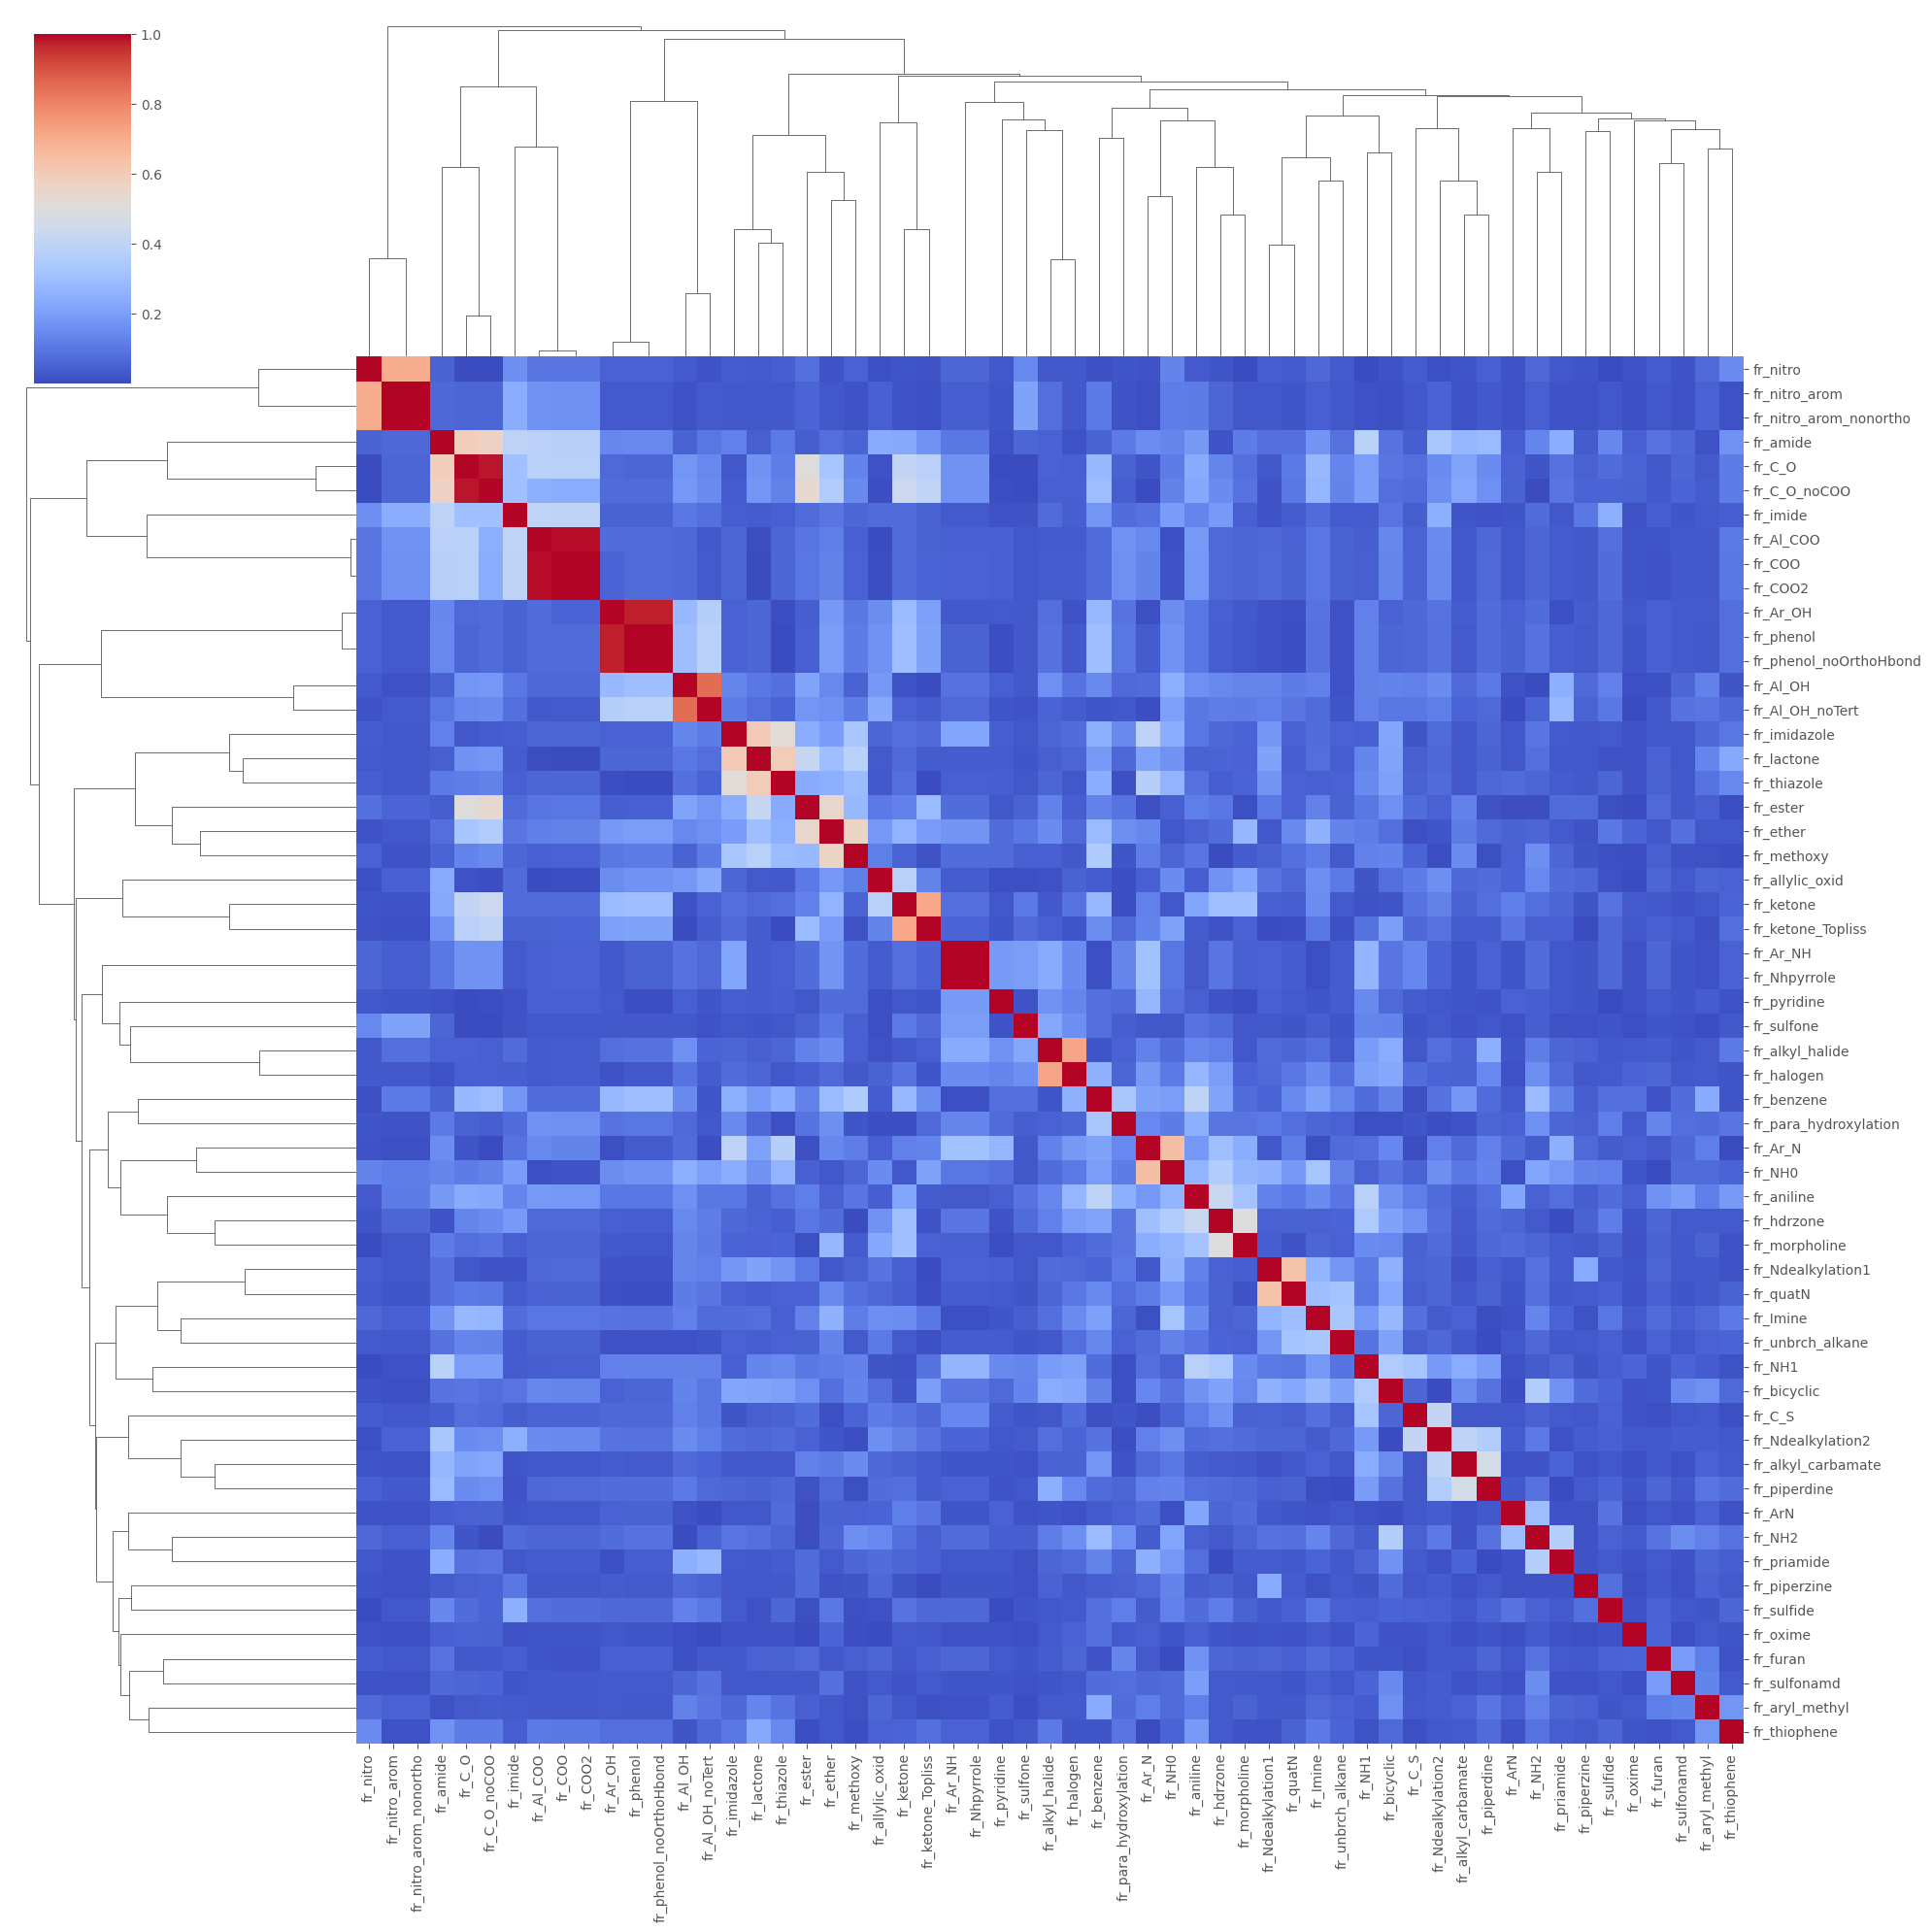

In [18]:
import seaborn as sns

sns.clustermap(
    corr,
    cmap='coolwarm',
    figsize=(20,20)
);

Теперь важно выбрать из полученных кластеров по одному признаку. Будем выбирать тот признак, у которого больше корреляция Спирмена с таргетами (будем суммировать абсолютные значения коэффициентов по трём таргетам).

In [19]:
cluster_ambiguous = [cluster for cluster in cluster_dict.values() if len(cluster) > 1]
cluster_ambiguous

[['fr_Al_COO', 'fr_COO', 'fr_COO2'],
 ['fr_Al_OH', 'fr_Al_OH_noTert'],
 ['fr_Ar_NH', 'fr_Nhpyrrole'],
 ['fr_Ar_OH', 'fr_phenol', 'fr_phenol_noOrthoHbond'],
 ['fr_C_O', 'fr_C_O_noCOO'],
 ['fr_nitro_arom', 'fr_nitro_arom_nonortho']]

In [20]:
from scipy.stats import spearmanr

cluster_features = [max({col: sum(abs(spearmanr(train[col], targets[tar])[0])
                    for tar in TARGETS)
                    for col in cluster}.items(), key=lambda x: x[1])
                    for cluster in cluster_ambiguous]
cluster_features

[('fr_Al_COO', np.float64(0.19236449971084157)),
 ('fr_Al_OH', np.float64(0.11305536915584319)),
 ('fr_Ar_NH', np.float64(0.10912739919625829)),
 ('fr_phenol', np.float64(0.30391398406503684)),
 ('fr_C_O', np.float64(0.32439688170571124)),
 ('fr_nitro_arom', np.float64(0.12223415034960347))]

In [21]:
train = train.drop(set(sum(cluster_ambiguous, start=[])) - dict(cluster_features).keys(), axis=1)
print(f'Осталось {train.shape[1]} из {len(FEATURES)} признаков')

Осталось 49 из 85 признаков


In [25]:
print(f'Оставленные признаки:\n {train.columns}')

Оставленные признаки:
 Index(['fr_Al_COO', 'fr_Al_OH', 'fr_ArN', 'fr_Ar_N', 'fr_Ar_NH', 'fr_C_O',
       'fr_C_S', 'fr_Imine', 'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_Ndealkylation1',
       'fr_Ndealkylation2', 'fr_alkyl_carbamate', 'fr_alkyl_halide',
       'fr_allylic_oxid', 'fr_amide', 'fr_aniline', 'fr_aryl_methyl',
       'fr_benzene', 'fr_bicyclic', 'fr_ester', 'fr_ether', 'fr_furan',
       'fr_halogen', 'fr_hdrzone', 'fr_imidazole', 'fr_imide', 'fr_ketone',
       'fr_ketone_Topliss', 'fr_lactone', 'fr_methoxy', 'fr_morpholine',
       'fr_nitro', 'fr_nitro_arom', 'fr_oxime', 'fr_para_hydroxylation',
       'fr_phenol', 'fr_piperdine', 'fr_piperzine', 'fr_priamide',
       'fr_pyridine', 'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone',
       'fr_thiazole', 'fr_thiophene', 'fr_unbrch_alkane'],
      dtype='object')


## Выводы по группе

**Качество данных:**
- Пропуски: отсутствуют
- Выбросы: есть, но разбираться с ними безопаснее всего на этапе Feature Engineering
- Проблемные признаки: после корреляционного анализа было оставлено 49 из 85 признаков

**Необходимые преобразования:**
- Масштабирование: оставим до этапа подбора гиперпараметров
- Импутация: нет пропусков, значит не нужна
- Удаление признаков: было удалено 36 признаков

**Наиболее коррелирующие с таргетами признаки:**
- IC50: оставим до этапа подбора гиперпараметров
- CC50: оставим до этапа подбора гиперпараметров
- SI: оставим до этапа подбора гиперпараметров

**Дополнительные замечания:**

На данный момент пока сделал акцент на удалении очевидно проблемных признаков. Всё остальное лучше оставить до этапов Подбора гиперепараметров и Feature Engineering.

**Оставленные признаки (на случай хардкодинга)**

['fr_Al_COO', 'fr_Al_OH', 'fr_ArN', 'fr_Ar_N', 'fr_Ar_NH', 'fr_C_O',
       'fr_C_S', 'fr_Imine', 'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_Ndealkylation1',
       'fr_Ndealkylation2', 'fr_alkyl_carbamate', 'fr_alkyl_halide',
       'fr_allylic_oxid', 'fr_amide', 'fr_aniline', 'fr_aryl_methyl',
       'fr_benzene', 'fr_bicyclic', 'fr_ester', 'fr_ether', 'fr_furan',
       'fr_halogen', 'fr_hdrzone', 'fr_imidazole', 'fr_imide', 'fr_ketone',
       'fr_ketone_Topliss', 'fr_lactone', 'fr_methoxy', 'fr_morpholine',
       'fr_nitro', 'fr_nitro_arom', 'fr_oxime', 'fr_para_hydroxylation',
       'fr_phenol', 'fr_piperdine', 'fr_piperzine', 'fr_priamide',
       'fr_pyridine', 'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone',
       'fr_thiazole', 'fr_thiophene', 'fr_unbrch_alkane']

# Как отправить результат на проверку (Pull Request)

После завершения анализа в вашей копии ноутбука выполните следующие шаги.

## 1. Скопируйте ваш ноутбук в репозиторий
- Убедитесь, что ноутбук сохранён на Google Диск.
- Переименуйте его по шаблону: `eda_group<номер>_<ваше_имя>.ipynb`
- В Colab выполните:

```python
from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/Colab Notebooks/eda_group1_Иван.ipynb" notebooks/
```

## 2. Создайте новую ветку
```python
!git checkout -b eda-group1-ivan
```

## 3. Закоммитьте и запушьте ветку
```python
!git add notebooks/eda_group1_Иван.ipynb
!git commit -m "EDA group 1: general molecular properties (Ivan)"
!git push origin eda-group1-ivan
```
При запросе пароля введите ваш токен GitHub.

## 4. Создайте Pull Request на GitHub
- Перейдите в репозиторий: https://github.com/NE1nthegame/jazz_team_project
- GitHub предложит создать PR из только что отправленной ветки — нажмите "Compare & pull request".
- Заголовок: например, "EDA Group 1: Общие молекулярные свойства (Иван)".
- В описании кратко укажите основные выводы.
- В правой панели Reviewers выберите одного из участников.
- Нажмите Create pull request.

## 5. Ревью и слияние
- Назначенный ревьюер просмотрит изменения и при необходимости оставит комментарии.
- Когда всё хорошо, ревьюер нажмёт Approve, а затем автор (или сам ревьюер) нажмёт Merge pull request.
- После слияния ветку можно удалить (кнопка "Delete branch").

## Важные правила
- НЕ коммитьте и не пушьте напрямую в main.
- Один Pull Request — один ноутбук (одна группа признаков).
- Перед коммитом очистите выводы ячеек: Runtime → Restart and run all и убедитесь, что всё работает.
- Проверьте, что в ноутбуке заполнена последняя Markdown-ячейка с выводами.

Если что-то пошло не так — обратитесь в общий чат.
